In [3]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle, Rectangle

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import iefc, dm, utils, shmim_utils, coro_utils

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()

    client = IndiClient()
    client.connect()
    client.get_properties()

INFO:purepyindi2.transports:Connected to localhost:7624


In [4]:
reload(coro_utils)

camsci_channel = 'camsci'
dm_channel = 'dm00disp01'

xc, yc = (4580, 2110)
ncamsci = 256
# coro_utils.set_zwo_roi(xc, yc, npsf, client0)

coro_utils.set_cam_roi(xc, yc, ncamsci, client0, cam_name=camsci_channel)
coro_utils.set_cam_exp_time(0.001, client0, cam_name=camsci_channel)
coro_utils.set_cam_gain(120, client0, cam_name=camsci_channel)
coro_utils.set_cam_blacklevel(2, client0, cam_name=camsci_channel)

Set camsci ROI.
Set the camsci exposure time to 1.00e-03s
Set the camsci gain setting to 120.0
Set the camsci blacklevel to 2.0


In [6]:
reload(coro_utils)
coro_utils.set_fiber_atten(0, client0)

Set the fiber attenuation to 0.0


In [ ]:
reload(coro_utils)
coro_utils.home_block(client0, delay=2.0)

In [8]:
coro_utils.move_block_out(client0)

In [16]:
reload(coro_utils)
coro_utils.move_psf(-10, 0, client0)

In [5]:
reload(coro_utils)
coro_utils.move_psf(0, -10, client0)

In [ ]:
CAMSCI_STREAM = ImageStream(camsci_channel)
DM_STREAM = ImageStream(dm_channel)

In [ ]:
Nact = 34
ncamsci = 256
iwa = 3
owa = 10
camsci_pxscl_lamDc = 0.307


dm_mask = dm.create_mask(Nact=34, return_np=1)

dh_mask = utils.create_annular_focal_plane_mask(
    ncamsci,
    camsci_pxscl_lamDc,
    iwa, 
    owa,  
    edge=iwa,
    centering='odd', # odd or even
    rotation=90,
    x_shift=0,
    y_shift=0,
    return_np=1,
)

utils.imshow([dm_mask, dh_mask])

In [ ]:
reload(scoobi)
# xc, yc = (4200, 2950)
xc, yc = (3900, 2575)
ncamsci = 256
xc, yc = (3875, 2575)
ncamsci = 128
coro_utils.set_cam_roi(xc, yc, ncamsci, client0, cam_name=camsci_channel)
coro_utils.set_cam_exp_time(0.005, client0, cam_name=camsci_channel)
coro_utils.set_cam_gain(120, client0, cam_name=camsci_channel)
coro_utils.set_cam_blacklevel(2, client0, cam_name=camsci_channel)

camsci_stream = ImageStream(camsci_channel)


Set camlo ROI.
Set the camlo exposure time to 5.00e-03s
Set the camlo gain setting to 120.0
Set the camlo blacklevel to 2.0


# Do the normalization

In [ ]:
coro_utils.move_psf(50, 0, client0)

In [ ]:
coro_utils.move_psf(0, -50, client0)

In [ ]:
coro_utils.move_psf(50, 0, client0)

In [ ]:
coro_utils.move_psf(0, -50, client0)

In [ ]:
reload(scoobi)
coro_utils.set_fib_atten(28, client)
coro_utils.set_cam_exp_time(0.0005, client0, cam_name=camsci_channel)
coro_utils.set_cam_gain(120, client0, cam_name=camsci_channel)


Set the fiber attenuation to 28.0
Set the camlo exposure time to 5.00e-04s
Set the camlo gain setting to 120.0


0


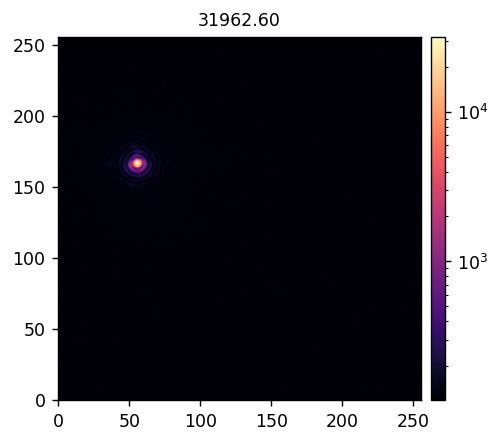

In [ ]:
reload(scoobi)
ref_psf = coro_utils.snap(camsci_stream, 200)
Iref = np.max(ref_psf)
utils.imshow([ref_psf], titles=[f'{Iref:.2f}'], norms=[LogNorm()])


In [ ]:
reload(scoobi)
ref_psf_params = coro_utils.get_im_params(client0, client, cam_name=camsci_channel)
ref_psf_params.update({'Iref': Iref})
utils.save_pickle(iefc_data_path/f'{today}_ref_psf_params.pkl', ref_psf_params)

# ref_psf_params = utils.load_pickle(data_path/f'{today}_ref_psf_params.pkl')

print(ref_psf_params)

Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250331/iefc/20250331_ref_psf_params.pkl
{'texp': 0.000500000023748726, 'gain': 120.0, 'atten': 28.0, 'Iref': np.float64(31962.6)}


# Move back onto the vortex and adjust exposure times

In [ ]:
coro_utils.move_psf(-50, 0, client0)

In [ ]:
coro_utils.move_psf(0, 50, client0)

In [ ]:
coro_utils.move_psf(-1, 0, client0)

In [ ]:
coro_utils.move_psf(0, -1, client0)

In [ ]:
coro_utils.set_fib_atten(0, client)
coro_utils.set_cam_exp_time(0.005, client0, cam_name=camsci_channel)
coro_utils.set_cam_gain(120, client0, cam_name=camsci_channel)

im_params = coro_utils.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':0.0})
print(im_params)

Set the fiber attenuation to 0.0
Set the camlo exposure time to 5.00e-03s
Set the camlo gain setting to 120.0
{'texp': 0.00499999988824129, 'gain': 120.0, 'atten': 0.0}


In [ ]:
reload(scoobi)
coro_utils.move_block_in(client0)

Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250331/iefc/20250331_camsci_dark_frame_0.005000.pkl
0


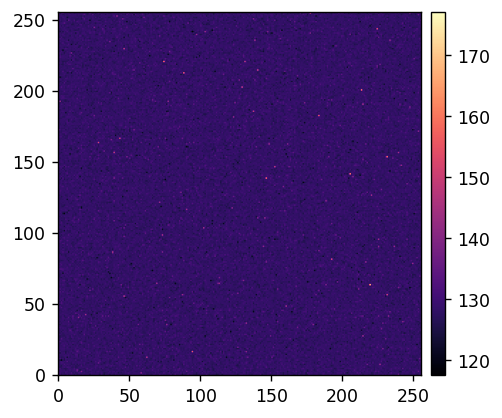

In [ ]:
reload(scoobi)
dark_frame = coro_utils.snap(camsci_stream, 500)
utils.save_pickle(iefc_data_path/f'{today}_camsci_dark_frame_{im_params["texp"]:.6f}.pkl', dark_frame)

utils.imshow([dark_frame])

In [ ]:
reload(scoobi)
coro_utils.move_block_out(client0)

# Use a waffle pattern to figure out the centering of the science camera images. 

0


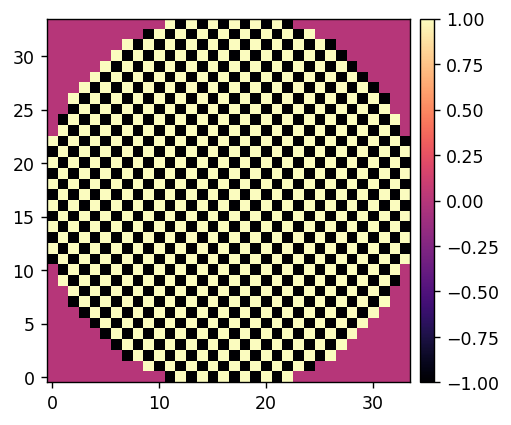

In [ ]:
reload(dm)
waffle_command = ensure_np_array(dm.make_fourier_command(x_cpa=17, y_cpa=17)) * dm_mask
utils.imshow([waffle_command])

In [ ]:
reload(scoobi)
coro_utils.set_dm(dm_ho_stream, 10e-9 * waffle_command)
waffle_im = coro_utils.snap(camsci_stream, 100, dark_frame, im_params, ref_psf_params)
utils.imshow([waffle_im], norms=[LogNorm()], cmaps=['magma'], grids=[1], pxscls=[camsci_pxscl_lamDc])

INFO:utils:Got semaphore index 1.


ValueError: operands could not be broadcast together with shapes (128,128) (256,256) 

Centroids:
 [[ 74.86462078  74.74503473]
 [ 70.22832865 167.30333012]
 [163.74489871 172.25566623]
 [168.68168325  79.79119322]
 [ 74.86462078  74.74503473]]
1


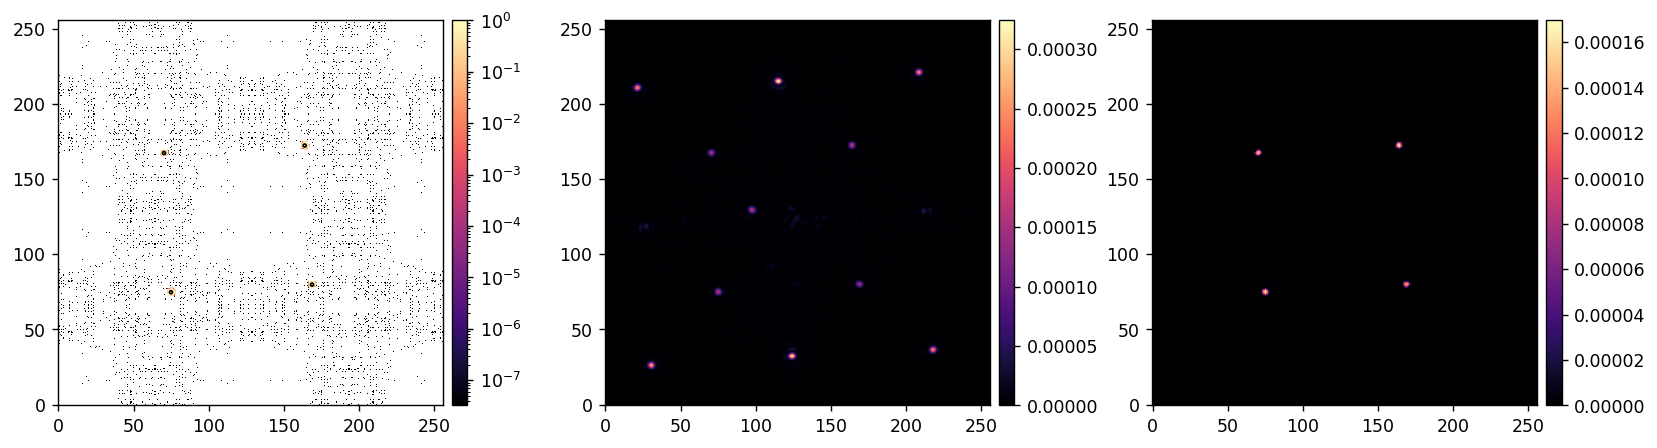

Angle:  86.99151360005212
Measured center in X:  119.3956273811497
Measured center in Y:  123.60004144095711
Required shift in X:  9.0
Required shift in Y:  4.0


In [ ]:
reload(utils)

xshift, yshift, angle = utils.measure_waffle_center_and_angle(
    xp.array(waffle_im), 
    camsci_pxscl_lamDc, 
    im_thresh=5e-5, 
    r_thresh_min=16,
    r_thresh_max=25,
)

# Create the mask defining the dark hole region. 

1022
0


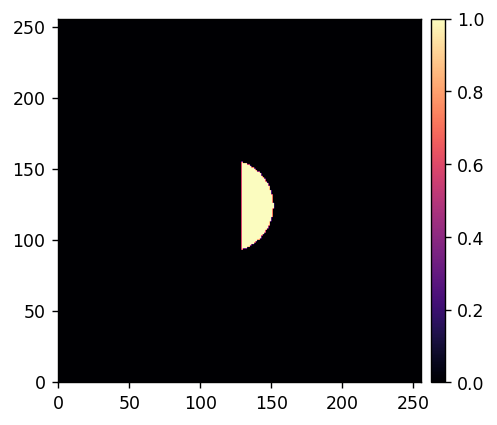

In [ ]:
reload(utils)
ncamsci = 256
iwa = 3
owa = 10
rotation = 0
control_mask = ensure_np_array( utils.create_annular_mask(
    ncamsci, 
    camsci_pxscl_lamDc,
    iwa, 
    owa, 
    edge=iwa, 
    x_shift=-xshift,
    y_shift=-yshift,
    rotation=rotation,
))
print(control_mask.sum())
utils.imshow([control_mask])

In [ ]:
coro_utils.set_fib_atten(0, client)
coro_utils.set_cam_exp_time(0.005, client0, cam_name=camsci_channel)
coro_utils.set_cam_gain(120, client0, cam_name=camsci_channel)

im_params = coro_utils.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':0.0})
print(im_params)

Set the fiber attenuation to 0.0
Set the camlo exposure time to 5.00e-03s
Set the camlo gain setting to 120.0
{'texp': 0.00499999988824129, 'gain': 120.0, 'atten': 0.0}


2.2310930320273484e-06
1


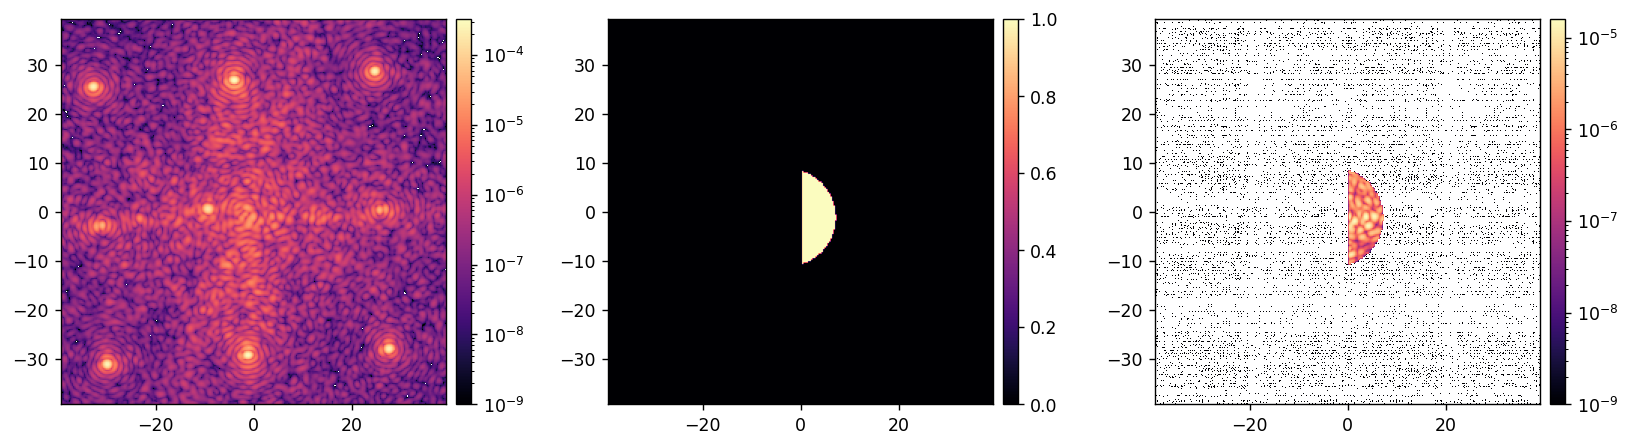

In [ ]:
coro_utils.zero_dm(dm_ho_stream)

ref_coro_im = coro_utils.snap(camsci_stream, 100, dark_frame, im_params, ref_psf_params)
print(np.mean(ref_coro_im[control_mask]))
utils.imshow(
    [ref_coro_im, control_mask, control_mask * ref_coro_im],
    norms=[LogNorm(1e-9), None, LogNorm(1e-9)],
    pxscls=[camsci_pxscl_lamDc]*3,
    cmaps=['magma']*3,
)